# Crack Detection — Step-by-step Demo
Run each cell to see the pipeline stage by stage. Good for the presentation.

In [21]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import cv2
import matplotlib.pyplot as plt
from pipeline import detect_cracks, overlay_mask
from evaluate import pixel_metrics

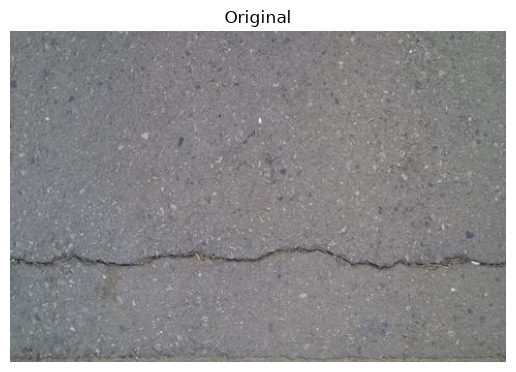

In [22]:
# 1) Load an image (put a file in data/raw/images/ first)
img_path = '../data/raw/images/005.jpg'
image = cv2.imread(img_path)
assert image is not None, 'Image not found - add one to data/raw/images/'
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)); plt.title('Original'); plt.axis('off');

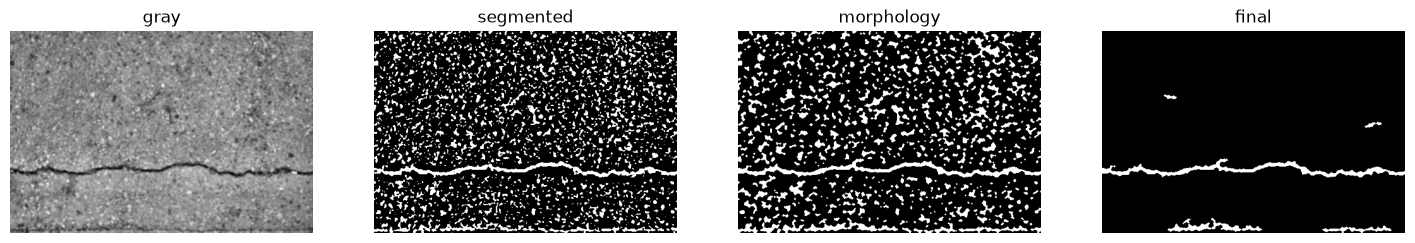

In [23]:
# 2) Run the pipeline and view every stage
mask, stages = detect_cracks(image, return_stages=True)
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
for a, (name, im) in zip(ax, stages.items()):
    a.imshow(im, cmap='gray'); a.set_title(name); a.axis('off')
plt.show()

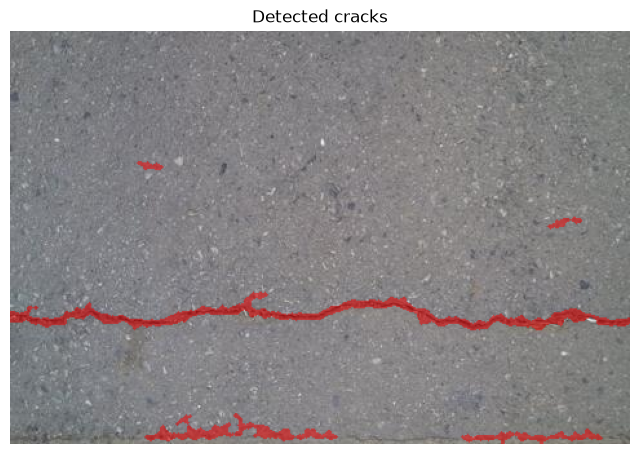

In [24]:
# 3) Overlay result on the original
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(overlay_mask(image, mask), cv2.COLOR_BGR2RGB))
plt.title('Detected cracks'); plt.axis('off'); plt.show()

In [25]:
# 4) Evaluate this image against its ground-truth mask
gt = cv2.imread('../data/raw/masks/005.png', cv2.IMREAD_GRAYSCALE)
if gt is not None:
    print(pixel_metrics(mask, gt))
else:
    print('No ground-truth mask found for this image.')

{'precision': 0.0123, 'recall': 0.0248, 'iou': 0.0083, 'dice': 0.0164}
